In [2]:
!pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 890.3 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.7 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.7 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/9.7 MB 1.3 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.7 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/9.7 MB 1.5 MB/s eta 0:00:06
   ---------- ----------------------------- 2.6/9.7 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 3.1/9.7 MB 1.5 MB/s eta 0:00:05
   ------------- -------------------------- 3.4/9.7 MB 1.5 MB/s eta 0:00:05
   --------------- -------------------

In [1]:
import pandas as pd
import json

def load_wikisql(data_path, table_path):
    # Load the questions/queries
    data = []
    with open(data_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    
    # Load the table metadata
    tables = {}
    with open(table_path, 'r', encoding='utf-8') as f:
        for line in f:
            t = json.loads(line)
            tables[t['id']] = t
            
    df = pd.DataFrame(data)
    # Map the table headers to the main dataframe for easier access
    df['table_header'] = df['table_id'].apply(lambda x: tables[x]['header'])
    return df


df_train = load_wikisql(r'C:\Users\salma\OneDrive\Desktop\projects\the github code for sql project\SQL-queries-analysis-Text-data-Analysis-Machine-learning\data\train.jsonl', r'C:\Users\salma\OneDrive\Desktop\projects\the github code for sql project\SQL-queries-analysis-Text-data-Analysis-Machine-learning\data\train.tables.jsonl')
print(df_train.head())

   phase      table_id                                           question  \
0      1   1-1000181-1    Tell me what the notes are for South Australia    
1      1   1-1000181-1  What is the current series where the new serie...   
2      1   1-1000181-1            What is the format for South Australia?   
3      1   1-1000181-1  Name the background colour for the Australian ...   
4      1  1-10007452-3      how many times is the fuel propulsion is cng?   

                                                 sql  \
0  {'sel': 5, 'conds': [[3, 0, 'SOUTH AUSTRALIA']...   
1  {'sel': 4, 'conds': [[5, 0, 'New series began ...   
2  {'sel': 2, 'conds': [[0, 0, 'South Australia']...   
3  {'sel': 1, 'conds': [[0, 0, 'Australian Capita...   
4     {'sel': 3, 'conds': [[5, 0, 'CNG']], 'agg': 3}   

                                        table_header  
0  [State/territory, Text/background colour, Form...  
1  [State/territory, Text/background colour, Form...  
2  [State/territory, Text/backgroun

In [6]:
df_test = load_wikisql(r'C:\Users\salma\OneDrive\Desktop\projects\the github code for sql project\SQL-queries-analysis-Text-data-Analysis-Machine-learning\data\test.jsonl', r'C:\Users\salma\OneDrive\Desktop\projects\the github code for sql project\SQL-queries-analysis-Text-data-Analysis-Machine-learning\data\test.tables.jsonl')


In [7]:
df_train.shape

(56355, 5)

In [9]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.8 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.1 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.1 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.7 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.1 MB 1.7 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 1.7 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 1.7 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.1 MB 1.7 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.1 MB 1.6 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.1 MB 1.6 MB/s eta 0:00:04
   ------------------ --------------------- 3.7/8.1 MB 1.5 MB/s eta 0:00:03
   -------------------- --

In [12]:
!pip install seaborn

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


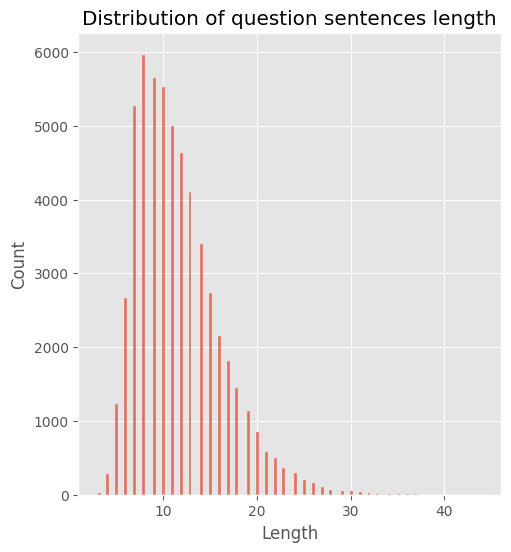

In [3]:
plt.figure(figsize=(12, 6))
plt.style.use('ggplot')
plt.subplot(1, 2, 1)
sns.histplot(df_train['question'].str.split().apply(len))
plt.title('Distribution of question sentences length')
plt.xlabel('Length')



plt.show()

In [4]:
# Helper dictionary to map WikiSQL aggregation IDs to SQL keywords
agg_ops = ['', 'MAX', 'MIN', 'COUNT', 'SUM', 'AVG']
cond_ops = ['=', '>', '<', 'OP']

def reconstruct_sql(row):
    sql_meta = row['sql']
    headers = row['table_header']
    
    # 1. Handle SELECT and AGGREGATION
    agg_idx = sql_meta['agg']
    sel_idx = sql_meta['sel']
    col_name = headers[sel_idx]
    
    if agg_idx > 0:
        select_clause = f"SELECT {agg_ops[agg_idx]}({col_name})"
    else:
        select_clause = f"SELECT {col_name}"
        
    # 2. Handle WHERE conditions
    where_clauses = []
    for cond in sql_meta['conds']:
        c_idx, o_idx, val = cond
        c_name = headers[c_idx]
        op = cond_ops[o_idx]
        # Wrap string values in quotes
        val_str = f"'{val}'" if isinstance(val, str) else str(val)
        where_clauses.append(f"{c_name} {op} {val_str}")
        
    query = select_clause + " FROM table"
    if where_clauses:
        query += " WHERE " + " AND ".join(where_clauses)
        
    return query

# Print 5 examples
for idx, row in df_train.head(5).iterrows():
    print(f"Sample #{idx + 1}")
    print(f"Question: {row['question']}")
    print(f"SQL:      {reconstruct_sql(row)}")
    print("-" * 50)

Sample #1
Question: Tell me what the notes are for South Australia 
SQL:      SELECT Notes FROM table WHERE Current slogan = 'SOUTH AUSTRALIA'
--------------------------------------------------
Sample #2
Question: What is the current series where the new series began in June 2011?
SQL:      SELECT Current series FROM table WHERE Notes = 'New series began in June 2011'
--------------------------------------------------
Sample #3
Question: What is the format for South Australia?
SQL:      SELECT Format FROM table WHERE State/territory = 'South Australia'
--------------------------------------------------
Sample #4
Question: Name the background colour for the Australian Capital Territory
SQL:      SELECT Text/background colour FROM table WHERE State/territory = 'Australian Capital Territory'
--------------------------------------------------
Sample #5
Question: how many times is the fuel propulsion is cng?
SQL:      SELECT COUNT(Fleet Series (Quantity)) FROM table WHERE Fuel Propulsion = 

# Feature Engineering

In [5]:
!pip install transformers torch

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.3/10.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/10.6 MB 3.8 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/10.6 MB 3.8 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/10.6 MB 3.0 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/10.6 MB 3.2 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/10.6 MB 2.8 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/10.6 MB 2.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/10.6 MB 2.6 MB/s eta 0:00:03
   ---------------------- ----------------- 6.0/10.6 MB 3.4 MB/s eta 0:00:02
   -------------------------- ------------- 7.1/10.6 MB 3.5 MB/s eta 0:00:02
   ----------------------------- ---------- 7.9/10.6 MB 3.5 MB/s eta 0:00:01
   -------------------------------- ------- 8.7/10.6 MB 3.5 MB/s eta 0:00:01
   ----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import torch
from transformers import BertTokenizerFast

c:\Users\salma\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:

# Initialize the fast tokenizer for BERT
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

def tokenize_wikisql_data(df, max_length=512):
    tokenized_inputs = []
    
    for idx, row in df.iterrows():
        question = row['question']
        # Join all headers with the separator token
        headers = f" {tokenizer.sep_token} ".join(row['table_header'])
        
        # Tokenize the pair (Question + Headers)
        encoding = tokenizer(
            question,                     # Text segment A
            headers,                      # Text segment B
            max_length=max_length,         # Pad/Truncate to a fixed size
            padding='max_length',
            truncation=True,
            return_tensors="pt",          # Return PyTorch tensors
            return_offsets_mapping=True,  # Keeps track of character positions
            return_token_type_ids=True    # Generates 0s for question, 1s for headers
        )
        
        tokenized_inputs.append(encoding)
        
    return tokenized_inputs

# Example usage on your training dataframe split
# (Truncating to 10 rows just for a quick test run)
sample_tokenized = tokenize_wikisql_data(df_train.head(10))
print(f"Successfully tokenized {len(sample_tokenized)} rows.")

c:\Users\salma\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\salma\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Successfully tokenized 10 rows.


In [8]:
# Extract the first tokenized row
first_row = sample_tokenized[0]

print("--- Tokenization Breakdown ---")
# 1. Input IDs (The numerical representations)
print(f"Input IDs Shape: {first_row['input_ids'].shape}") 
print(f"First 15 Input IDs: {first_row['input_ids'][0][:15].tolist()}")

# 2. Decode back to human readable text to see structural layout
decoded_text = tokenizer.decode(first_row['input_ids'][0][:40])
print(f"\nDecoded Layout Concept:\n{decoded_text}...")

# 3. Token Type IDs (Segments)
# Look at where it switches from 0 (Question) to 1 (Headers)
print(f"\nToken Type IDs (First 15): {first_row['token_type_ids'][0][:15].tolist()}")

# 4. Attention Mask
print(f"Attention Mask (First 15): {first_row['attention_mask'][0][:15].tolist()}")

--- Tokenization Breakdown ---
Input IDs Shape: torch.Size([1, 512])
First 15 Input IDs: [101, 2425, 2033, 2054, 1996, 3964, 2024, 2005, 2148, 2660, 102, 2110, 1013, 3700, 102]

Decoded Layout Concept:
[CLS] tell me what the notes are for south australia [SEP] state / territory [SEP] text / background colour [SEP] format [SEP] current slogan [SEP] current series [SEP] notes [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]...

Token Type IDs (First 15): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
Attention Mask (First 15): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
